In [1]:
from matplotlib import animation as animation
from matplotlib import patches as patches
from matplotlib import pyplot as plt
from matplotlib import colormaps

import numpy as np

from IPython.display import HTML

In [2]:
sub_path = np.concatenate((4 * np.arange(100)[:, None], 40 * np.ones(100)[:, None]), axis=-1)

In [3]:
sub_path.shape

(100, 2)

In [4]:
M     = 1e-21                  # mass (kg)
L     = 400                    # length (meters) 
Q_MIN = np.array([0. , 0.  ])  # minimum box displacements
Q_MAX = np.array([L  , L/5.])  # maximum box displacements

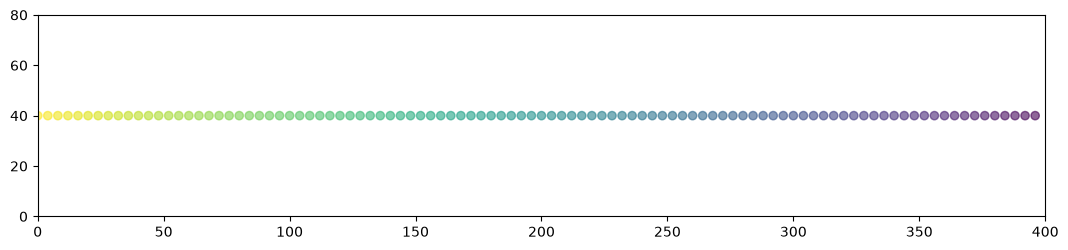

In [5]:
fig, ax = plt.subplots(figsize=(13, 13))
ax.scatter(*sub_path.T, cmap="viridis", c=range(sub_path.shape[0])[::-1], edgecolors=None, alpha=0.6)
ax.set_xlim(Q_MIN[0], Q_MAX[0])
ax.set_ylim(Q_MIN[1], Q_MAX[1])
ax.set(aspect="equal")
plt.show()

In [9]:
# code modified from https://matplotlib.org/stable/gallery/animation/simple_scatter.html
# inspiration of code to plot accumulating points is from https://stackoverflow.com/a/57964570

fig, ax = plt.subplots(figsize=(12, 3), layout="constrained")
plt.close() # prevent a double plot, thanks to https://stackoverflow.com/a/18718162

# turn axis off, thanks to https://stackoverflow.com/a/8218887
# linked to from https://stackoverflow.com/a/9295367
ax.set_axis_off()

# modified from https://matplotlib.org/stable/gallery/images_contours_and_fields/image_exact_placement.html
ax.add_patch(patches.Rectangle(Q_MIN, Q_MAX[0], Q_MAX[1], edgecolor='k', linewidth=1, facecolor='none'))

ax.set(aspect="equal")

scat = ax.scatter([], [])

def animate(i):
    scat.set_offsets(sub_path[:i])
    colors = colormaps['viridis'](np.linspace(1, 0, i))
    colors[:, -1] = 0.6
    scat.set_color(colors)
    return scat,

ani = animation.FuncAnimation(fig, animate, frames=sub_path.shape[0]-1, interval=10, blit=True, repeat=True, repeat_delay=2000)

# To save the animation using Pillow as a gif
writer = animation.PillowWriter(fps=60, metadata=dict(artist="dyth"), bitrate=1800)
ani.save("scatter.gif", writer=writer)

# displaying the animation is from https://stackoverflow.com/questions/43445103/inline-animations-in-jupyter#43447370
# linked to from https://interactivetextbooks.tudelft.nl/open-textbooks-demonstration/content/Basic_animation_demo.html 
HTML(ani.to_jshtml())